In [24]:
#pip install scikit-image scikit-learn matplotlib numpy
#pip install natsort
import numpy as np
from skimage import io, img_as_float
from sklearn.metrics import mutual_info_score
from skimage.util.shape import view_as_windows
import matplotlib.pyplot as plt
from pyod.models.iforest import IForest
from sklearn.ensemble import IsolationForest
from scipy.stats import entropy
from sklearn.preprocessing import minmax_scale
import os
from natsort import natsorted
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

import warnings
warnings.filterwarnings("ignore")


# Parameters
input_path = '/home/nc3397/Work/MI/adv_test'  # Path to adversarial image
output_path = '/home/nc3397/Work/MI/adv_def_test'  # Path to save the reconstructed image
window_size = (50,50)  # Define the size of the moving window
step_size = 10  # Define the step size for the moving window
variance_retained = 0.95  # Define the percentage of variance to retain


def img2double(img):
    info = np.finfo(img.dtype)
    return img.astype(float) / info.max


def svd(img, full_matrices=False):
    U, S, VT = np.linalg.svd(img, full_matrices=full_matrices)
    return (U, np.diag(S), VT)


def perc_storage(rank, n_rows, n_cols):
    original_space = n_rows*n_cols
    compressed_space = n_rows*rank + rank + n_cols*rank
    return compressed_space / original_space * 100


def perc_energy(S, r):
    return (np.trace(S[:r]) / np.trace(S)) * 100


def frobenious_norm(A, B):
    return np.linalg.norm(A-B, ord='fro')


def get_optimal_rank_by_energy(X, max_energy):
    _, S, _ = svd(X)
    max_rank_ = S.shape[0]
    opt_rank_ = 1
    
    while True:
        energy = perc_energy(S, opt_rank_)
        if energy < max_energy:
            opt_rank_ += 1
            continue
        if energy > max_energy:
            opt_rank_ -= 1
        
        break
        
    return opt_rank_
    

def get_optimal_rank_by_storage(X, max_storage):
    _, S, _ = svd(X)
    max_rank_ = S.shape[0]
    opt_rank_ = 1
    
    while True:
        storage = perc_storage(opt_rank_, *S.shape)
        if storage < max_storage:
            opt_rank_ += 1
            continue
        if storage > max_storage:
            opt_rank_ -= 1
        
        break

    return opt_rank_


def get_optimal_rank_by_norm(X, max_norm):
    U, S, VT = svd(X)
    max_rank_ = S.shape[0]
    opt_rank_ = 1
    
    while True:
        X_r = U[:, :opt_rank_] @ S[:opt_rank_, :opt_rank_] @ VT[:opt_rank_, :]

        norm = frobenious_norm(X, X_r)
        if norm > max_norm:
            opt_rank_ += 1
            continue
        
        break
        
    return opt_rank_


def get_optimal_rank(X, by='energy', **kwargs):
    VALID_BY = ['energy', 'storage', 'norm']
    
    if not isinstance(by, str):
        raise ValueError(f'by should be of type `str` but got {type(by)}')
        
    if by not in VALID_BY:
        raise ValueError(f'by should be one of {VALID_BY}')
        
    if by == 'energy':
        
        if len(X.shape) == 3:
            opt_rank_ = np.mean(
                [
                    get_optimal_rank_by_energy(X[:, :, 0], kwargs['max_energy']),
                    get_optimal_rank_by_energy(X[:, :, 1], kwargs['max_energy']),
                    get_optimal_rank_by_energy(X[:, :, 2], kwargs['max_energy']),
                ]
            )
        else:
            opt_rank_ = get_optimal_rank_by_energy(X, kwargs['max_energy'])
            
    elif by == 'storage':
        
        if len(X.shape) == 3:
            opt_rank_ = np.mean(
                [
                    get_optimal_rank_by_storage(X[:, :, 0], kwargs['max_storage']),
                    get_optimal_rank_by_storage(X[:, :, 1], kwargs['max_storage']),
                    get_optimal_rank_by_storage(X[:, :, 2], kwargs['max_storage']),
                ]
            )
        else:
            opt_rank_ = get_optimal_rank_by_storage(X, kwargs['max_storage'])

    else:
        
        if len(X.shape) == 3:
            opt_rank_ = np.mean(
                [
                    get_optimal_rank_by_norm(X[:, :, 0], kwargs['max_norm']),
                    get_optimal_rank_by_norm(X[:, :, 1], kwargs['max_norm']),
                    get_optimal_rank_by_norm(X[:, :, 2], kwargs['max_norm']),
                ]
            )
        else:
            opt_rank_ = get_optimal_rank_by_norm(X, kwargs['max_norm'])

    return int(opt_rank_)

def calculate_mutual_information(chunk):
    """Calculate the mutual information score between a chunk and the full image."""
    flattened_chunk = chunk.ravel()
    #flattened_full_image = full_image.ravel()
    return mutual_info_score(flattened_chunk, flattened_chunk)


# Calculate entropy for a single chunk
def calculate_entropy(chunk):
    """Calculates the entropy of a chunk."""
    chunk_flat = chunk.flatten()
    histogram, _ = np.histogram(chunk_flat, bins=256, range=(0, 1), density=True)
    return entropy(histogram)


# Calculate entropy for a single chunk
def calculate_mutual_info_score(chunk):
    """Calculates the entropy of a chunk."""
    chunk_flat = chunk.flatten()
    histogram, _ = np.histogram(chunk_flat, bins=256, range=(0, 1), density=True)
    return entropy(histogram)


def split_image_into_chunks(image, window_size, step_size):
    """Split the image into chunks using a moving window."""
    chunks = view_as_windows(image, window_size, step_size)
    return chunks

def apply_svd_to_chunk(chunk, variance_retained):
    """Apply Singular Value Decomposition (SVD) to a chunk and retain enough singular values to preserve specified variance."""
    U, S, Vt = np.linalg.svd(chunk, full_matrices=False)
    total_variance = np.sum(S ** 2)
    variance_covered = 0
    k = 0
    while variance_covered / total_variance < variance_retained and k < len(S):
        variance_covered += S[k] ** 2
        k += 1
    U_k = U[:, :k]
    S_k = S[:k]
    Vt_k = Vt[:k, :]
    return U_k, S_k, Vt_k

def calculate_entropy_score(chunk, full_image):
    """Calculate the mutual information score between a chunk and the full image."""
    flattened_chunk = chunk.ravel()
    flattened_full_image = full_image.ravel()
    return mutual_info_score(flattened_chunk, flattened_chunk)


def reconstruct_chunk(U, S, Vt):
    """Reconstruct the chunk from its reduced SVD representation."""
    return np.dot(U, np.dot(np.diag(S), Vt))

def scale_to_ubyte(image):
    """Scale the image to 0-255 and convert to uint8."""
    image = (image - np.min(image)) / (np.max(image) - np.min(image))
    return (image * 255).astype(np.uint8)


# Autoencoder Model
class ChunkAutoencoder(nn.Module):
    def __init__(self):
        super(ChunkAutoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=2, stride=2),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

    
# Training Function
def train_autoencoder(model, dataloader, epochs=5, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            batch = batch.to(device)
            optimizer.zero_grad()
            outputs = model(batch)
            loss = criterion(outputs, batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(dataloader):.4f}")
    
def get_imagenet_dataloader(data_dir, batch_size=32):
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    dataset = datasets.ImageFolder(root=os.path.join('./val/'), transform=transform) 
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader    
    
def get_autoencoder(chunks):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ChunkAutoencoder().to(device)
    #DataLoader
    imagenet_data_path = './val/'  # Set the actual ImageNet validation dataset path
    dataloader = get_imagenet_dataloader(imagenet_data_path, batch_size=32)
    # Train Autoencoder
    train_autoencoder(model, dataloader, epochs=10, lr=0.001)
    return model    
    
# Function to Process Chunks using Autoencoder
def process_chunks(chunks, model):
    """
    Takes a stack of image chunks and returns the processed (reconstructed) chunks.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    chunks = torch.tensor(chunks, dtype=torch.float32).to(device).unsqueeze(0)
    #chunks = chunks.permute(0, 3, 1, 2)
    with torch.no_grad():
        processed_chunks = model(chunks)
    return processed_chunks.cpu()




def main_ODDR(image_path, window_size, step_size, variance_retained):
    # Read the image
    image = img_as_float(io.imread(image_path, as_gray=True))
    color_image = img_as_float(io.imread(image_path))

    # Split the image into chunks
    chunks = split_image_into_chunks(image, window_size, step_size)

    # Reshape chunks for Isolation Forest
    reshaped_chunks = chunks.reshape(-1, window_size[0] * window_size[1])

    # Fit Isolation Forest
    iso_forest = IsolationForest(n_estimators=500,contamination=0.1)
    iso_forest.fit(reshaped_chunks)
    anomaly_scores = iso_forest.decision_function(reshaped_chunks)

    # Find the top 2 outlier chunks
    top_indices = np.argsort(anomaly_scores)[:5]
    top_indices_2d = np.dstack(np.unravel_index(top_indices, chunks.shape[:2]))[0]
    top_chunks = [chunks[tuple(index)] for index in top_indices_2d]

    # Apply SVD to the top chunks
    reconstructed_chunks = []
    for chunk in top_chunks:
        U, S, Vt = apply_svd_to_chunk(chunk, variance_retained)
        reconstructed_chunks.append(reconstruct_chunk(U, S, Vt))

    return color_image, anomaly_scores, top_indices_2d, top_chunks, reconstructed_chunks



# Parameters
#image_path = '/home/nc3397/Work/MI/samples/image_3_YOLO.jpg'  # Path to your image
#output_path = '/home/nc3397/Work/MI/samples/image_3_YOLO_reconstructed.jpg'  # Path to save the reconstructed image
#window_size = (50, 50)  # Define the size of the moving window
#step_size = 10  # Define the step size for the moving window
#variance_retained = 0.95  # Define the percentage of variance to retain

# Run the main function
#color_image, mi_scores, max_index, max_chunk, reconstructed_chunk = main(image_path, window_size, step_size, variance_retained)

# Visualize and save the image with the SVD-reduced chunk
#visualize_and_save_reconstructed_image(color_image, reconstructed_chunk, max_index, window_size, step_size, output_path)

# Print the SVD results for the chunk with the highest mutual information score
#print(f"Highest mutual information score: {mi_scores[max_index]}")
#print(f"Chunk at index {max_index}:")
#print(f"Reconstructed chunk (truncated):\n{reconstructed_chunk}")




def MySVD(image, variability_perc):
    img = image.detach().cpu().numpy()
    max_energy=variability_perc
    max_storage=50
    max_norm=20

    opt_rank_by_energy = get_optimal_rank(img, by='energy', max_energy=max_energy)
    opt_rank_by_storage = get_optimal_rank(img, by='storage', max_storage=max_storage)
    opt_rank_by_norm = get_optimal_rank(img, by='norm', max_norm=max_norm)

    rank = opt_rank_by_energy

    RANKS = [rank]

    red_channel, green_channel, blue_channel =  img[:, :, 0], img[:, :, 1], img[:, :, 2]

    U_B, S_B, VT_B = svd(blue_channel)
    U_G, S_G, VT_G = svd(green_channel)
    U_R, S_R, VT_R = svd(red_channel)
    

    for idx, r in enumerate(RANKS):
        XR_r = U_R[:, :r] @ S_R[:r, :r] @ VT_R[:r, :]
        XG_r = U_G[:, :r] @ S_G[:r, :r] @ VT_G[:r, :]
        XB_r = U_B[:, :r] @ S_B[:r, :r] @ VT_B[:r, :]
    
        X_r = np.dstack((XR_r, XG_r, XB_r))
    
        info_stored = np.mean(
            [
                perc_energy(S_R, r),
                perc_energy(S_G, r),
                perc_energy(S_B, r),
            ]
        )

        frob_norm = np.mean(
                [
                    frobenious_norm(red_channel, XR_r),
                    frobenious_norm(green_channel, XG_r),
                    frobenious_norm(blue_channel, XB_r),
                ]
            )
    #print(rank) 
    #print(frob_norm)
    img_dr = torch.from_numpy(np.transpose(X_r))
    img_dr = img_dr.cuda()
    return img_dr, rank


def visualize_and_save_reconstructed_image_batch(color_image, reconstructed_chunks, top_indices, window_size, step_size, output_path):
    """Visualize and save the color image with the chunks replaced by their SVD-reduced versions."""
    reconstructed_image = color_image.copy()
    for reconstructed_chunk, index in zip(reconstructed_chunks, top_indices):
        y = index[0] * step_size
        x = index[1] * step_size

        # Replace the chunk in all color channels
        for c in range(color_image.shape[2]):
            reconstructed_image[y:y+window_size[0], x:x+window_size[1], c] = reconstructed_chunk

        # Highlight the replaced chunk
        #rect = plt.Rectangle((x, y), window_size[1], window_size[0],linewidth=2, edgecolor='r', facecolor='none')
        #plt.gca().add_patch(rect)

    # Scale the reconstructed image to 0-255 and convert to uint8
    reconstructed_image_uint8 = scale_to_ubyte(reconstructed_image)

    # Save the reconstructed image
    #io.imsave(output_path, reconstructed_image_uint8)

    # Visualize the image
    #plt.imshow(reconstructed_image_uint8)
    #plt.show()
    return reconstructed_image_uint8



def process_image(image_path, window_size, step_size, variance_retained):
    color_image, mi_scores, top_indices, top_chunks, reconstructed_chunks = main_ODDR(image_path, window_size, step_size, variance_retained)
    reconstructed_image = visualize_and_save_reconstructed_image_batch(color_image, reconstructed_chunks, top_indices, window_size, step_size, output_path)
    return reconstructed_image

#Use main_PB for PatchBlock
#Use main_ODDR for ODDR
#Use main_JEDI for Jedi (set window_size to 64,64 to fit the autoencoder)


import time

new_number = -1
path = os.listdir(input_path)
path = natsorted(path)
start_time = time.time()
for filename in path:
    image_path = os.path.join(input_path, filename)
    processed_image = process_image(image_path,window_size, step_size, variance_retained)
    #file_name_without_extension, number = os.path.splitext(filename)[0], int(filename[-5:])
    new_number = new_number +1
    new_filename = f"defended_{new_number}.jpg"
    io.imsave(os.path.join(output_path, new_filename), processed_image)
end_time = time.time()
execution_time = end_time - start_time  # Calculate time taken
print(f"Execution Time: {execution_time:.4f} seconds")

Execution Time: 0.0836 seconds


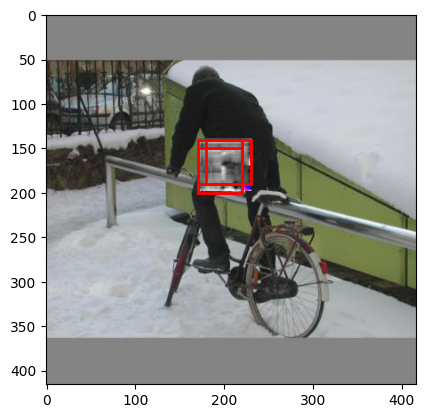

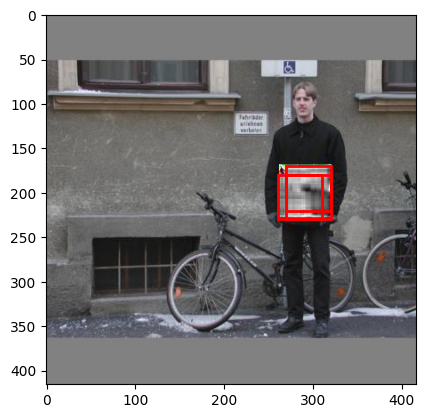

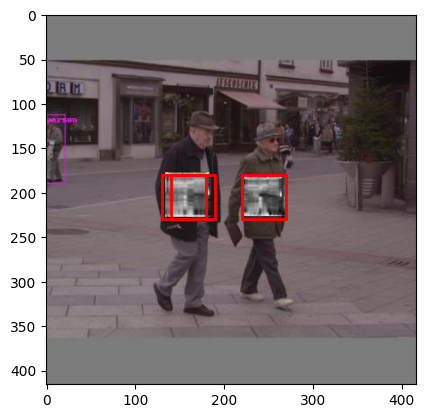

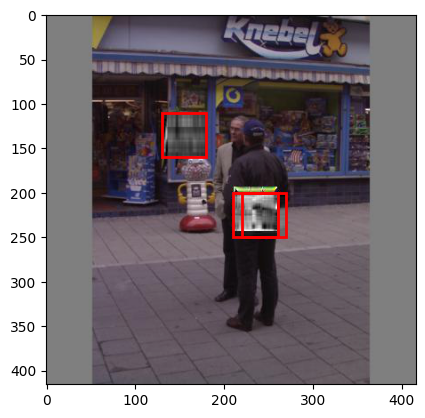

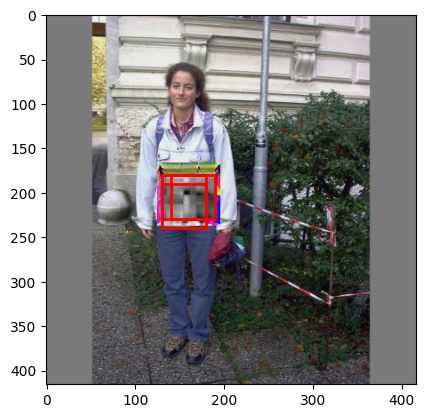

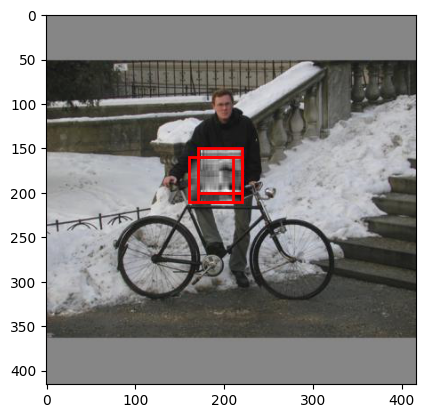

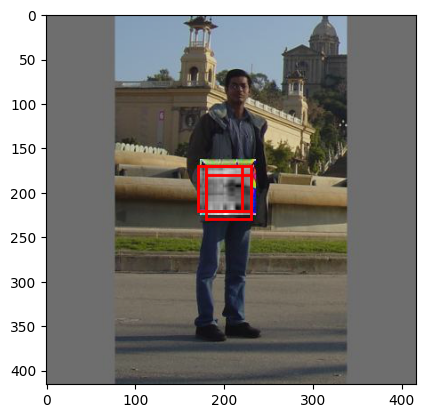

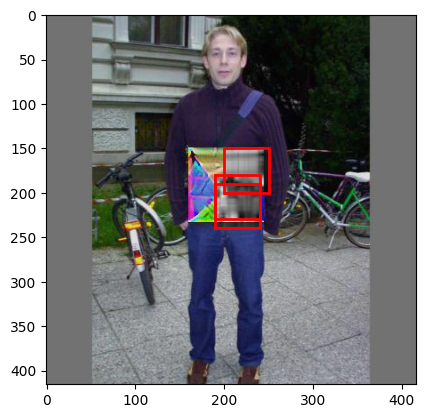

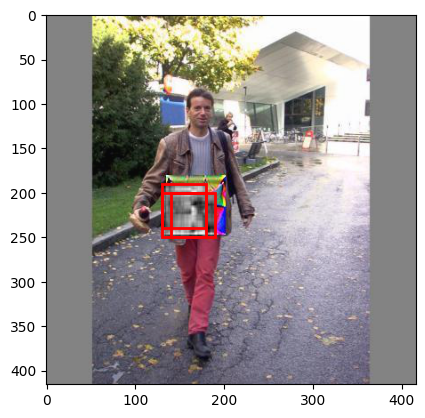

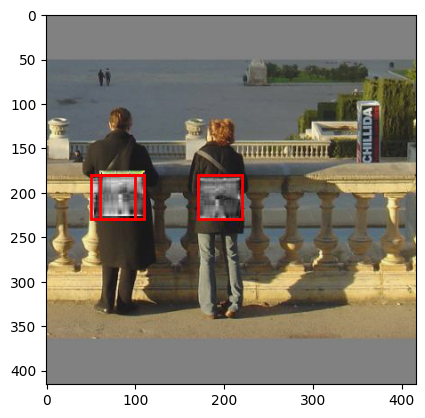

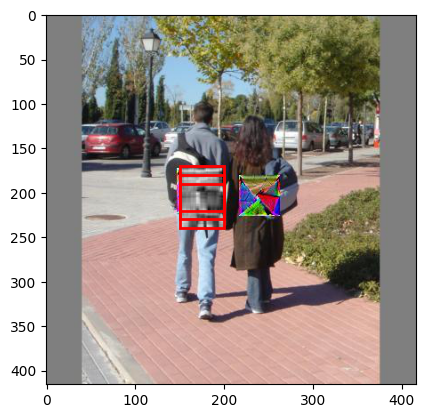

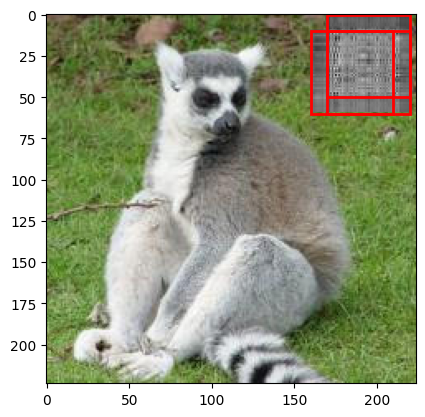

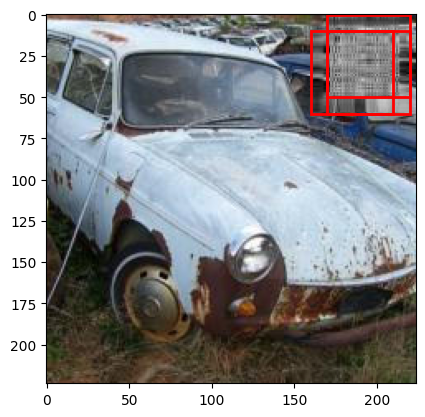

Execution Time: 15.6747 seconds


In [30]:
#pip install scikit-image scikit-learn matplotlib numpy
#pip install natsort
import numpy as np
from skimage import io, img_as_float
from sklearn.metrics import mutual_info_score
from skimage.util.shape import view_as_windows
import matplotlib.pyplot as plt
from pyod.models.iforest import IForest
from sklearn.ensemble import IsolationForest
from scipy.stats import entropy
from sklearn.preprocessing import minmax_scale
import os
from natsort import natsorted
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

import warnings
warnings.filterwarnings("ignore")


# Parameters
input_path = '/home/nc3397/Work/MI/samples/demo'  # Path to adversarial image
output_path = '/home/nc3397/Work/MI/samples/def'  # Path to save the reconstructed image
window_size = (50,50)  # Define the size of the moving window
step_size = 10  # Define the step size for the moving window
variance_retained = 0.95  # Define the percentage of variance to retain


def img2double(img):
    info = np.finfo(img.dtype)
    return img.astype(float) / info.max


def svd(img, full_matrices=False):
    U, S, VT = np.linalg.svd(img, full_matrices=full_matrices)
    return (U, np.diag(S), VT)


def perc_storage(rank, n_rows, n_cols):
    original_space = n_rows*n_cols
    compressed_space = n_rows*rank + rank + n_cols*rank
    return compressed_space / original_space * 100


def perc_energy(S, r):
    return (np.trace(S[:r]) / np.trace(S)) * 100


def frobenious_norm(A, B):
    return np.linalg.norm(A-B, ord='fro')


def get_optimal_rank_by_energy(X, max_energy):
    _, S, _ = svd(X)
    max_rank_ = S.shape[0]
    opt_rank_ = 1
    
    while True:
        energy = perc_energy(S, opt_rank_)
        if energy < max_energy:
            opt_rank_ += 1
            continue
        if energy > max_energy:
            opt_rank_ -= 1
        
        break
        
    return opt_rank_
    

def get_optimal_rank_by_storage(X, max_storage):
    _, S, _ = svd(X)
    max_rank_ = S.shape[0]
    opt_rank_ = 1
    
    while True:
        storage = perc_storage(opt_rank_, *S.shape)
        if storage < max_storage:
            opt_rank_ += 1
            continue
        if storage > max_storage:
            opt_rank_ -= 1
        
        break

    return opt_rank_


def get_optimal_rank_by_norm(X, max_norm):
    U, S, VT = svd(X)
    max_rank_ = S.shape[0]
    opt_rank_ = 1
    
    while True:
        X_r = U[:, :opt_rank_] @ S[:opt_rank_, :opt_rank_] @ VT[:opt_rank_, :]

        norm = frobenious_norm(X, X_r)
        if norm > max_norm:
            opt_rank_ += 1
            continue
        
        break
        
    return opt_rank_


def get_optimal_rank(X, by='energy', **kwargs):
    VALID_BY = ['energy', 'storage', 'norm']
    
    if not isinstance(by, str):
        raise ValueError(f'by should be of type `str` but got {type(by)}')
        
    if by not in VALID_BY:
        raise ValueError(f'by should be one of {VALID_BY}')
        
    if by == 'energy':
        
        if len(X.shape) == 3:
            opt_rank_ = np.mean(
                [
                    get_optimal_rank_by_energy(X[:, :, 0], kwargs['max_energy']),
                    get_optimal_rank_by_energy(X[:, :, 1], kwargs['max_energy']),
                    get_optimal_rank_by_energy(X[:, :, 2], kwargs['max_energy']),
                ]
            )
        else:
            opt_rank_ = get_optimal_rank_by_energy(X, kwargs['max_energy'])
            
    elif by == 'storage':
        
        if len(X.shape) == 3:
            opt_rank_ = np.mean(
                [
                    get_optimal_rank_by_storage(X[:, :, 0], kwargs['max_storage']),
                    get_optimal_rank_by_storage(X[:, :, 1], kwargs['max_storage']),
                    get_optimal_rank_by_storage(X[:, :, 2], kwargs['max_storage']),
                ]
            )
        else:
            opt_rank_ = get_optimal_rank_by_storage(X, kwargs['max_storage'])

    else:
        
        if len(X.shape) == 3:
            opt_rank_ = np.mean(
                [
                    get_optimal_rank_by_norm(X[:, :, 0], kwargs['max_norm']),
                    get_optimal_rank_by_norm(X[:, :, 1], kwargs['max_norm']),
                    get_optimal_rank_by_norm(X[:, :, 2], kwargs['max_norm']),
                ]
            )
        else:
            opt_rank_ = get_optimal_rank_by_norm(X, kwargs['max_norm'])

    return int(opt_rank_)

def calculate_mutual_information(chunk):
    """Calculate the mutual information score between a chunk and the full image."""
    flattened_chunk = chunk.ravel()
    #flattened_full_image = full_image.ravel()
    return mutual_info_score(flattened_chunk, flattened_chunk)


# Calculate entropy for a single chunk
def calculate_entropy(chunk):
    """Calculates the entropy of a chunk."""
    chunk_flat = chunk.flatten()
    histogram, _ = np.histogram(chunk_flat, bins=256, range=(0, 1), density=True)
    return entropy(histogram)


# Calculate entropy for a single chunk
def calculate_mutual_info_score(chunk):
    """Calculates the entropy of a chunk."""
    chunk_flat = chunk.flatten()
    histogram, _ = np.histogram(chunk_flat, bins=256, range=(0, 1), density=True)
    return entropy(histogram)


def split_image_into_chunks(image, window_size, step_size):
    """Split the image into chunks using a moving window."""
    chunks = view_as_windows(image, window_size, step_size)
    return chunks

def apply_svd_to_chunk(chunk, variance_retained):
    """Apply Singular Value Decomposition (SVD) to a chunk and retain enough singular values to preserve specified variance."""
    U, S, Vt = np.linalg.svd(chunk, full_matrices=False)
    total_variance = np.sum(S ** 2)
    variance_covered = 0
    k = 0
    while variance_covered / total_variance < variance_retained and k < len(S):
        variance_covered += S[k] ** 2
        k += 1
    U_k = U[:, :k]
    S_k = S[:k]
    Vt_k = Vt[:k, :]
    return U_k, S_k, Vt_k

def calculate_entropy_score(chunk, full_image):
    """Calculate the mutual information score between a chunk and the full image."""
    flattened_chunk = chunk.ravel()
    flattened_full_image = full_image.ravel()
    return mutual_info_score(flattened_chunk, flattened_chunk)


def reconstruct_chunk(U, S, Vt):
    """Reconstruct the chunk from its reduced SVD representation."""
    return np.dot(U, np.dot(np.diag(S), Vt))

def scale_to_ubyte(image):
    """Scale the image to 0-255 and convert to uint8."""
    image = (image - np.min(image)) / (np.max(image) - np.min(image))
    return (image * 255).astype(np.uint8)


# Autoencoder Model
class ChunkAutoencoder(nn.Module):
    def __init__(self):
        super(ChunkAutoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=2, stride=2),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

    
# Training Function
def train_autoencoder(model, dataloader, epochs=5, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            batch = batch.to(device)
            optimizer.zero_grad()
            outputs = model(batch)
            loss = criterion(outputs, batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(dataloader):.4f}")
    
def get_imagenet_dataloader(data_dir, batch_size=32):
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    dataset = datasets.ImageFolder(root=os.path.join('./val/'), transform=transform) 
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader    
    
def get_autoencoder(chunks):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ChunkAutoencoder().to(device)
    #DataLoader
    imagenet_data_path = './val/'  # Set the actual ImageNet validation dataset path
    dataloader = get_imagenet_dataloader(imagenet_data_path, batch_size=32)
    # Train Autoencoder
    train_autoencoder(model, dataloader, epochs=10, lr=0.001)
    return model    
    
# Function to Process Chunks using Autoencoder
def process_chunks(chunks, model):
    """
    Takes a stack of image chunks and returns the processed (reconstructed) chunks.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    chunks = torch.tensor(chunks, dtype=torch.float32).to(device).unsqueeze(0)
    #chunks = chunks.permute(0, 3, 1, 2)
    with torch.no_grad():
        processed_chunks = model(chunks)
    return processed_chunks.cpu()



def main_PB(image_path, window_size, step_size, variance_retained):
    # Read the image
    image = img_as_float(io.imread(image_path, as_gray=True))
    color_image = img_as_float(io.imread(image_path))

    # Split the image into chunks
    chunks = split_image_into_chunks(image, window_size, step_size)

    # Calculate mutual information score for each chunk
    mi_scores = np.zeros(chunks.shape[:2])
    for i in range(chunks.shape[0]):
        for j in range(chunks.shape[1]):
            mi_scores[i, j] = calculate_mutual_info_score(chunks[i, j])

    # Find the top 3 chunks with the highest mutual information scores
    top_indices = np.dstack(np.unravel_index(np.argsort(mi_scores.ravel())[-2:], mi_scores.shape))[0]
    top_chunks = [chunks[tuple(index)] for index in top_indices]

    # Apply SVD to the top chunks
    reconstructed_chunks = []
    for chunk in top_chunks:
        U, S, Vt = apply_svd_to_chunk(chunk, variance_retained)
        reconstructed_chunks.append(reconstruct_chunk(U, S, Vt))

    return color_image, mi_scores, top_indices, top_chunks, reconstructed_chunks


def main_ODDR(image_path, window_size, step_size, variance_retained):
    # Read the image
    image = img_as_float(io.imread(image_path, as_gray=True))
    color_image = img_as_float(io.imread(image_path))

    # Split the image into chunks
    chunks = split_image_into_chunks(image, window_size, step_size)

    # Reshape chunks for Isolation Forest
    reshaped_chunks = chunks.reshape(-1, window_size[0] * window_size[1])

    # Fit Isolation Forest
    iso_forest = IsolationForest(n_estimators=500,contamination=0.1)
    iso_forest.fit(reshaped_chunks)
    anomaly_scores = iso_forest.decision_function(reshaped_chunks)

    # Find the top 2 outlier chunks
    top_indices = np.argsort(anomaly_scores)[:5]
    top_indices_2d = np.dstack(np.unravel_index(top_indices, chunks.shape[:2]))[0]
    top_chunks = [chunks[tuple(index)] for index in top_indices_2d]

    # Apply SVD to the top chunks
    reconstructed_chunks = []
    for chunk in top_chunks:
        U, S, Vt = apply_svd_to_chunk(chunk, variance_retained)
        reconstructed_chunks.append(reconstruct_chunk(U, S, Vt))

    return color_image, anomaly_scores, top_indices_2d, top_chunks, reconstructed_chunks



# Parameters
#image_path = '/home/nc3397/Work/MI/samples/image_3_YOLO.jpg'  # Path to your image
#output_path = '/home/nc3397/Work/MI/samples/image_3_YOLO_reconstructed.jpg'  # Path to save the reconstructed image
#window_size = (50, 50)  # Define the size of the moving window
#step_size = 10  # Define the step size for the moving window
#variance_retained = 0.95  # Define the percentage of variance to retain

# Run the main function
#color_image, mi_scores, max_index, max_chunk, reconstructed_chunk = main(image_path, window_size, step_size, variance_retained)

# Visualize and save the image with the SVD-reduced chunk
#visualize_and_save_reconstructed_image(color_image, reconstructed_chunk, max_index, window_size, step_size, output_path)

# Print the SVD results for the chunk with the highest mutual information score
#print(f"Highest mutual information score: {mi_scores[max_index]}")
#print(f"Chunk at index {max_index}:")
#print(f"Reconstructed chunk (truncated):\n{reconstructed_chunk}")




def MySVD(image, variability_perc):
    img = image.detach().cpu().numpy()
    max_energy=variability_perc
    max_storage=50
    max_norm=20

    opt_rank_by_energy = get_optimal_rank(img, by='energy', max_energy=max_energy)
    opt_rank_by_storage = get_optimal_rank(img, by='storage', max_storage=max_storage)
    opt_rank_by_norm = get_optimal_rank(img, by='norm', max_norm=max_norm)

    rank = opt_rank_by_energy

    RANKS = [rank]

    red_channel, green_channel, blue_channel =  img[:, :, 0], img[:, :, 1], img[:, :, 2]

    U_B, S_B, VT_B = svd(blue_channel)
    U_G, S_G, VT_G = svd(green_channel)
    U_R, S_R, VT_R = svd(red_channel)
    

    for idx, r in enumerate(RANKS):
        XR_r = U_R[:, :r] @ S_R[:r, :r] @ VT_R[:r, :]
        XG_r = U_G[:, :r] @ S_G[:r, :r] @ VT_G[:r, :]
        XB_r = U_B[:, :r] @ S_B[:r, :r] @ VT_B[:r, :]
    
        X_r = np.dstack((XR_r, XG_r, XB_r))
    
        info_stored = np.mean(
            [
                perc_energy(S_R, r),
                perc_energy(S_G, r),
                perc_energy(S_B, r),
            ]
        )

        frob_norm = np.mean(
                [
                    frobenious_norm(red_channel, XR_r),
                    frobenious_norm(green_channel, XG_r),
                    frobenious_norm(blue_channel, XB_r),
                ]
            )
    #print(rank) 
    #print(frob_norm)
    img_dr = torch.from_numpy(np.transpose(X_r))
    img_dr = img_dr.cuda()
    return img_dr, rank


def visualize_and_save_reconstructed_image_batch(color_image, reconstructed_chunks, top_indices, window_size, step_size, output_path):
    """Visualize and save the color image with the chunks replaced by their SVD-reduced versions."""
    reconstructed_image = color_image.copy()
    for reconstructed_chunk, index in zip(reconstructed_chunks, top_indices):
        y = index[0] * step_size
        x = index[1] * step_size

        # Replace the chunk in all color channels
        for c in range(color_image.shape[2]):
            reconstructed_image[y:y+window_size[0], x:x+window_size[1], c] = reconstructed_chunk

        # Highlight the replaced chunk
        rect = plt.Rectangle((x, y), window_size[1], window_size[0],linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)

    # Scale the reconstructed image to 0-255 and convert to uint8
    reconstructed_image_uint8 = scale_to_ubyte(reconstructed_image)

    # Save the reconstructed image
    #io.imsave(output_path, reconstructed_image_uint8)

    # Visualize the image
    plt.imshow(reconstructed_image_uint8)
    plt.show()
    return reconstructed_image_uint8



def process_image(image_path, window_size, step_size, variance_retained):
    color_image, mi_scores, top_indices, top_chunks, reconstructed_chunks = main_ODDR(image_path, window_size, step_size, variance_retained)
    reconstructed_image = visualize_and_save_reconstructed_image_batch(color_image, reconstructed_chunks, top_indices, window_size, step_size, output_path)
    return reconstructed_image

#Use main_PB for PatchBlock
#Use main_ODDR for ODDR
#Use main_JEDI for Jedi (set window_size to 64,64 to fit the autoencoder)


import time

new_number = -1
path = os.listdir(input_path)
path = natsorted(path)
start_time = time.time()
for filename in path:
    image_path = os.path.join(input_path, filename)
    processed_image = process_image(image_path,window_size, step_size, variance_retained)
    #file_name_without_extension, number = os.path.splitext(filename)[0], int(filename[-5:])
    new_number = new_number +1
    new_filename = f"defended_{new_number}.jpg"
    io.imsave(os.path.join(output_path, new_filename), processed_image)
end_time = time.time()
execution_time = end_time - start_time  # Calculate time taken
print(f"Execution Time: {execution_time:.4f} seconds")